# Analyse uni-dimensionnelle des variables

In [ ]:
# Lire le fichier
data_features_core <- read.csv("data.csv")

# Vérifier que l'import s'est bien passé
head(data_features_core)

#séparation des var quali et quanti
var_quanti <- names(data_features_core)[sapply(data_features_core, is.numeric)]
var_quali  <- names(data_features_core)[sapply(data_features_core, is.factor)]


,Établissement,Statut.Etablissement,Filière.de.formation,Filière.de.formation.très.agrégée,Région.de.l.établissement,Académie.de.l.établissement,Sélectivité,Capacité.de.l.établissement.par.formation,Effectif.total.admis.2phases,Effectif.total.candidats.2phases,⋯,part_mention_tb_fel,part_mention_haute,score_mention,X..d.admis.néo.bacheliers.issus.de.la.même.académie..Paris.Créteil.Versailles.réunies.,X..d.admis.néo.bacheliers.généraux,X..d.admis.néo.bacheliers.technologiques,X..d.admis.néo.bacheliers.professionnels,log_candidats,log_admis,log_capacite
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>
1,INSTITUT DES SCIENCES ET TECHNIQUES DE LA READAPTATION UNIVERSITE LYON 1,Public,Certificat de capacité d'Orthoptiste,Autre formation,Auvergne-Rhône-Alpes,Lyon,formation sélective,40,40,936,⋯,0.00000000,0.30769231,1.7692308,31,85,15,0,6.842683,3.713572,3.713572
2,Université Paris 8,Public,Licence - Langues étrangères appliquées - Parcours Anglais / Italien,Licence,Ile-de-France,Créteil,formation non sélective,32,30,249,⋯,0.00000000,0.00000000,0.1666667,75,33,33,33,5.521461,3.433987,3.496508
3,IFSI du CH de Roanne,Public,D.E Infirmier,IFSI,Auvergne-Rhône-Alpes,Lyon,formation sélective,56,56,2791,⋯,0.00000000,0.02702703,0.9189189,84,38,51,11,7.934513,4.043051,4.043051
4,Université Claude Bernard Lyon 1,Public,Licence - Parcours d'Accès Spécifique Santé (PASS),PASS,Auvergne-Rhône-Alpes,Lyon,formation non sélective,195,194,5973,⋯,0.01675978,0.11731844,1.4525140,71,100,0,0,8.695172,5.273000,5.278115
5,Université Claude Bernard Lyon 1,Public,Licence - Parcours d'Accès Spécifique Santé (PASS),PASS,Auvergne-Rhône-Alpes,Lyon,formation non sélective,75,75,5472,⋯,0.04225352,0.33802817,2.2253521,75,99,1,0,8.607582,4.330733,4.330733
6,Université de Bordeaux - Antenne d'Agen,Public,Licence - Administration économique et sociale,Licence,Nouvelle Aquitaine,Bordeaux,formation non sélective,110,101,1719,⋯,0.00000000,0.04166667,0.6250000,65,50,40,10,7.450080,4.624973,4.709530


   Length     Class      Mode 
    14252 character character 

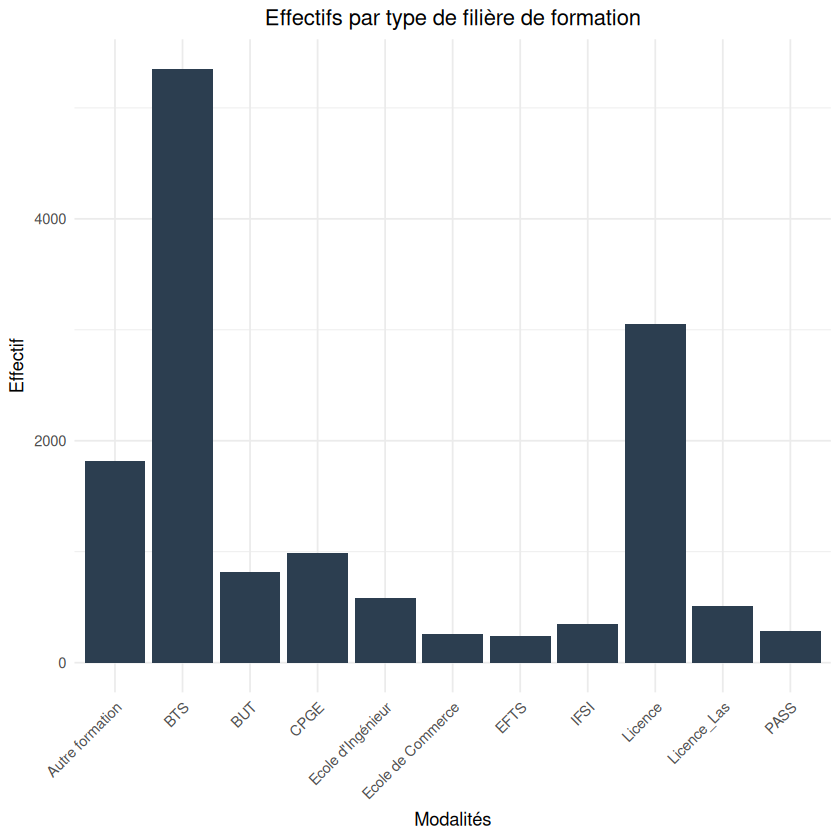

In [3]:
###Effectif par formation
summary(data_features_core$`Filière.de.formation.très.agrégée`)
library(ggplot2)

ggplot(data_features_core, aes(x = `Filière.de.formation.très.agrégée`)) +
  geom_bar(fill = "#2C3E50") +
  labs(
    title = "Effectifs par type de filière de formation",
    x = "Modalités",
    y = "Effectif"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5),
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

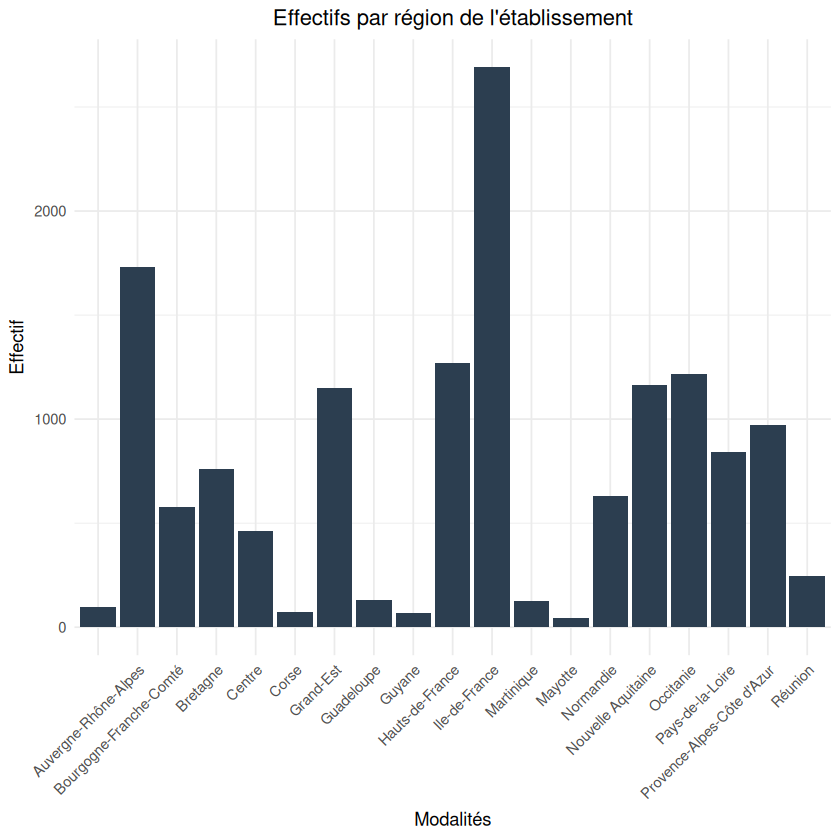

In [4]:
###Effectifs par région
ggplot(data_features_core, aes(x = Région.de.l.établissement)) +
  geom_bar(fill = "#2C3E50") +
  labs(
    title = "Effectifs par région de l'établissement",
    x = "Modalités",
    y = "Effectif"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5),
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


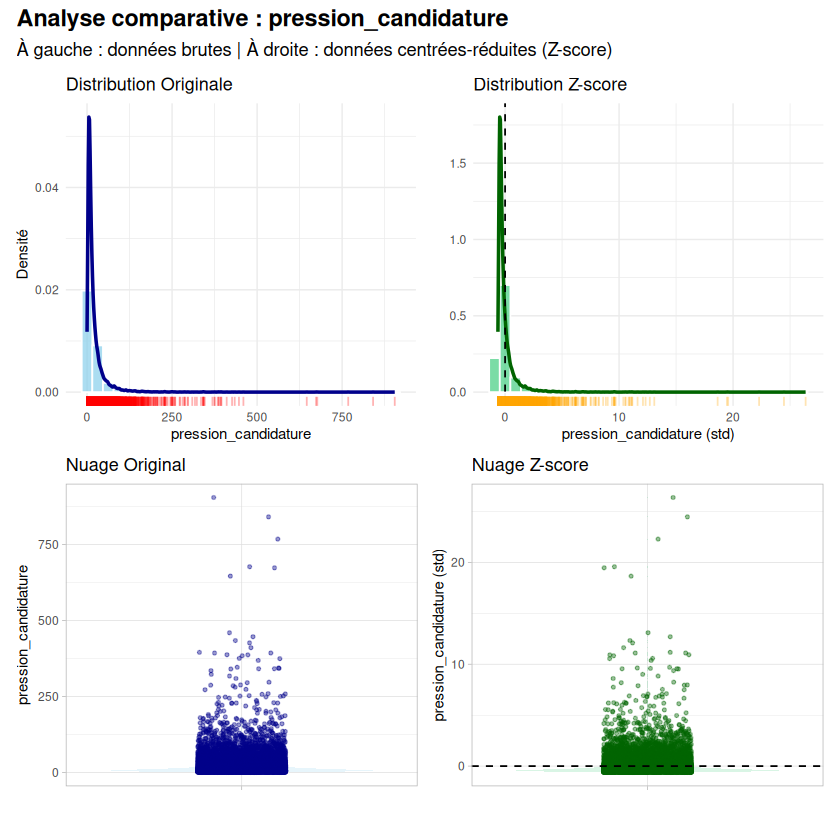

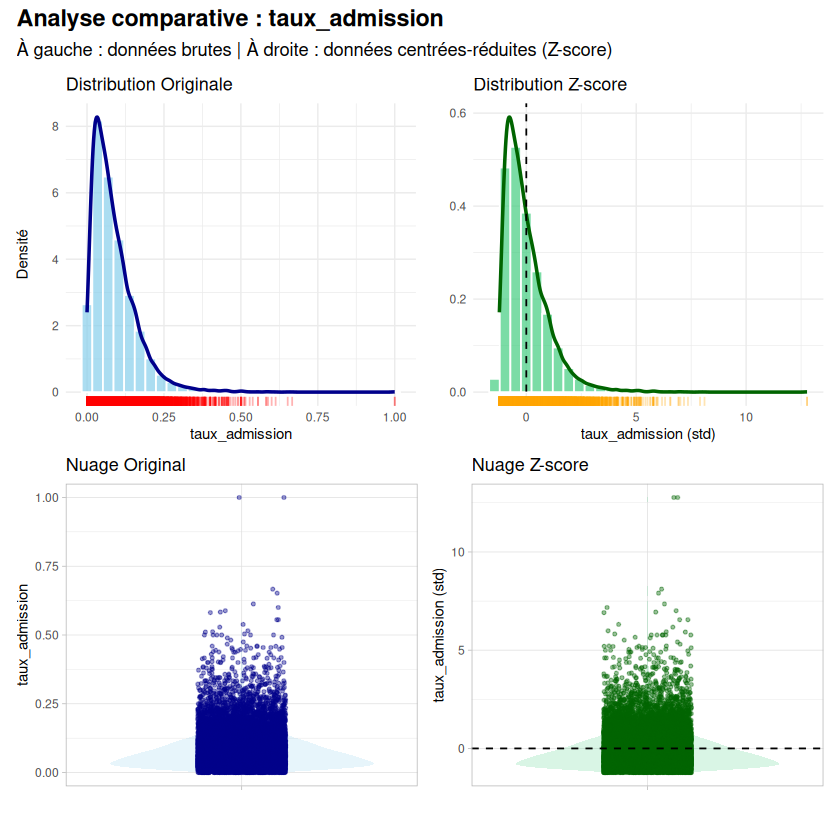

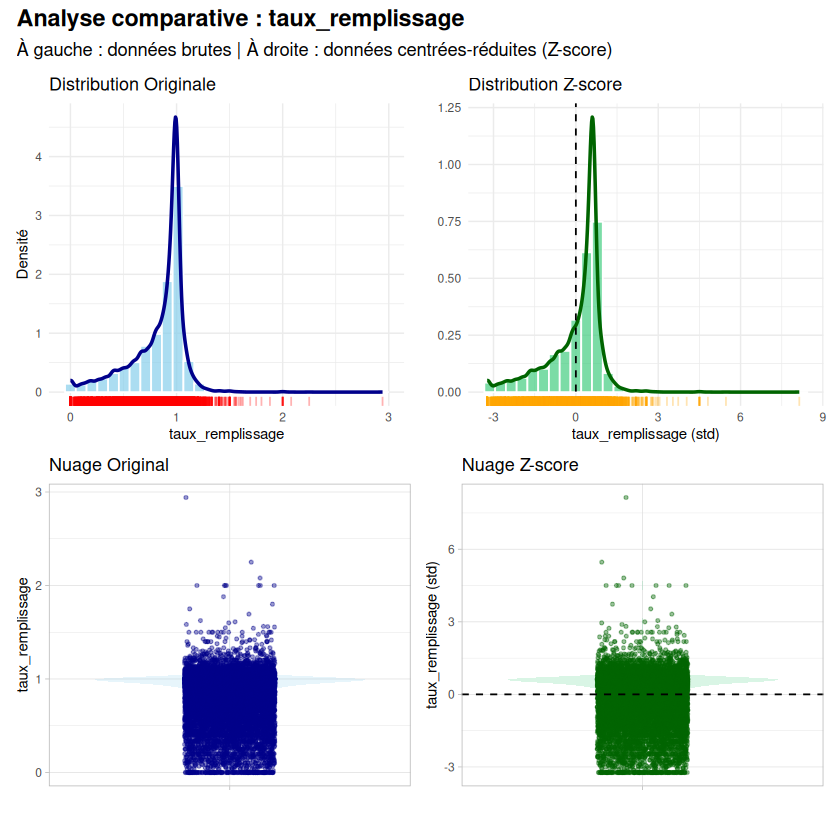

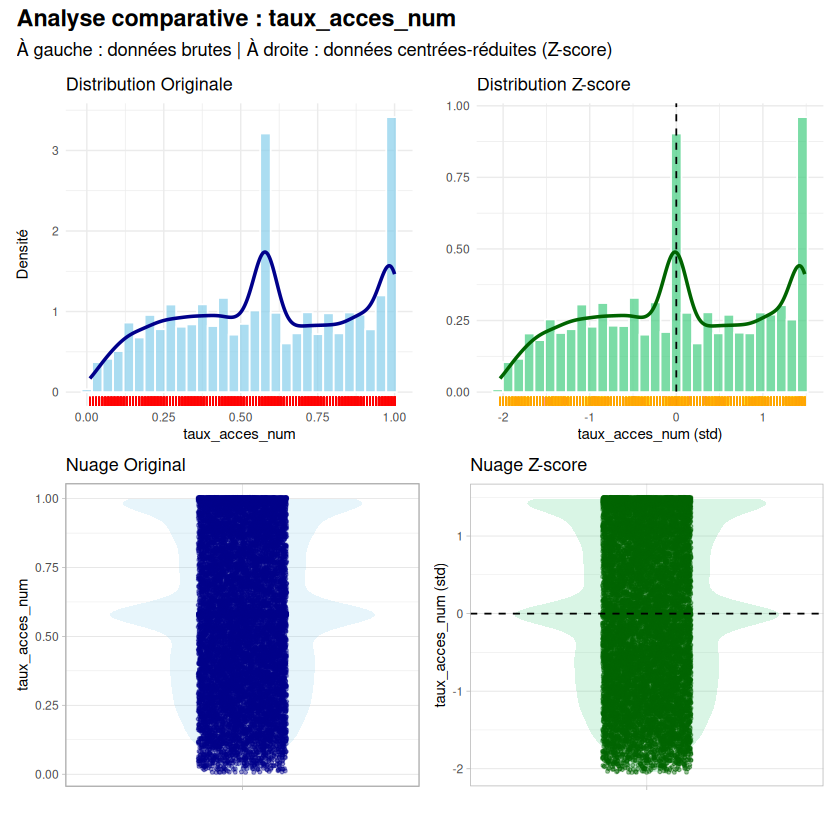

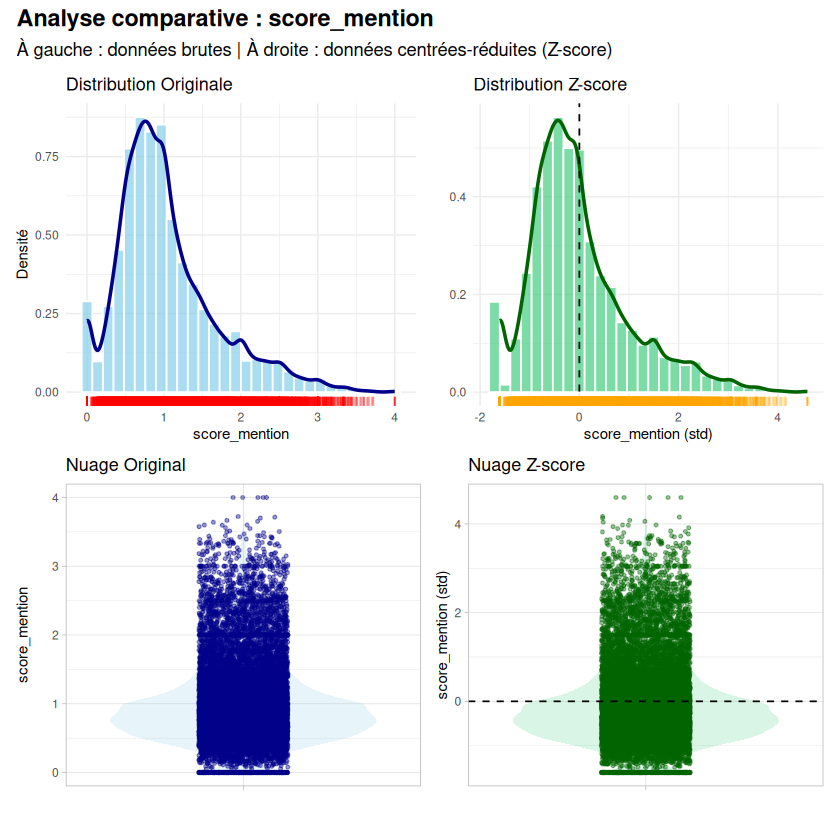

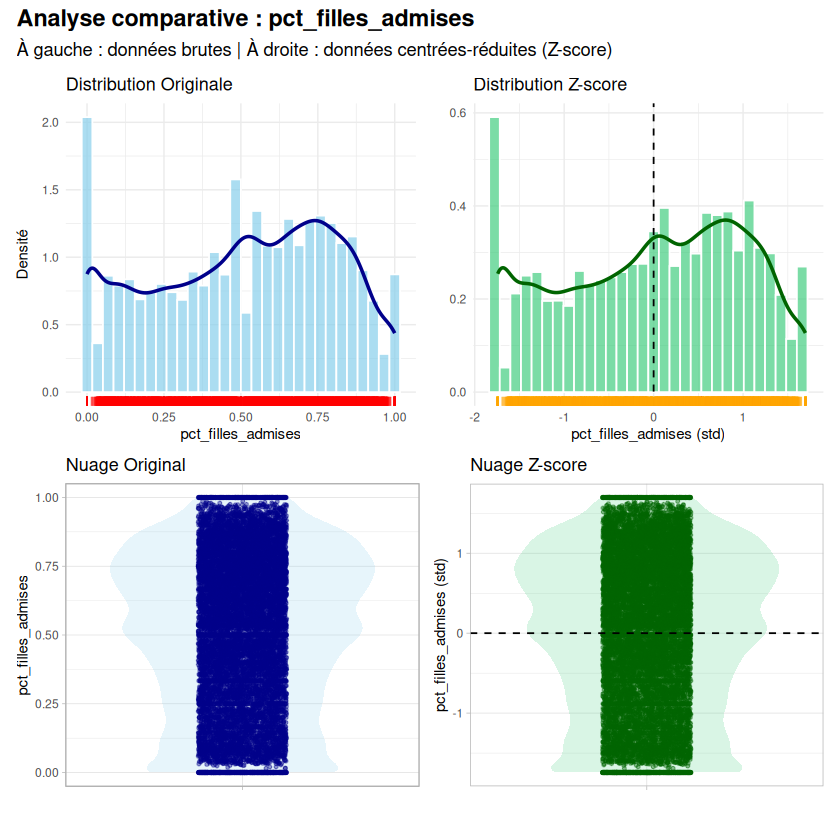

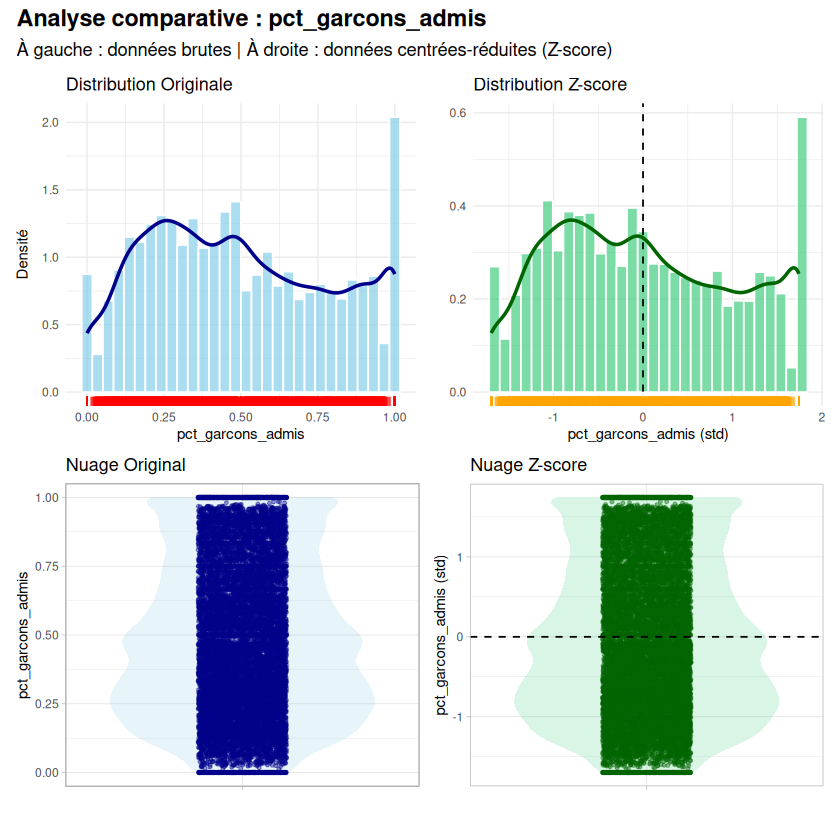

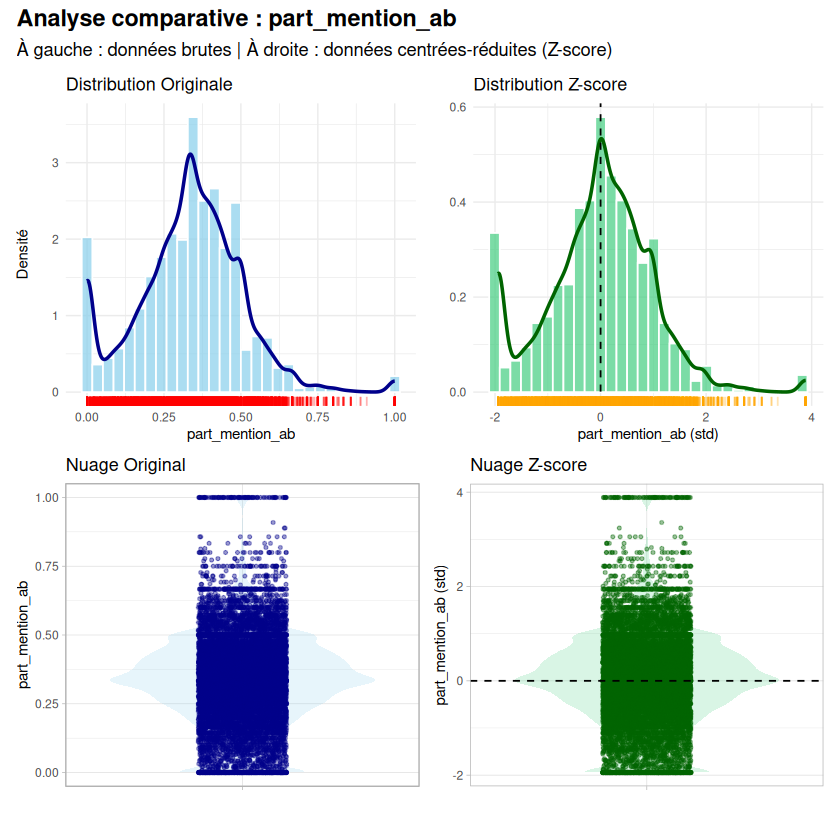

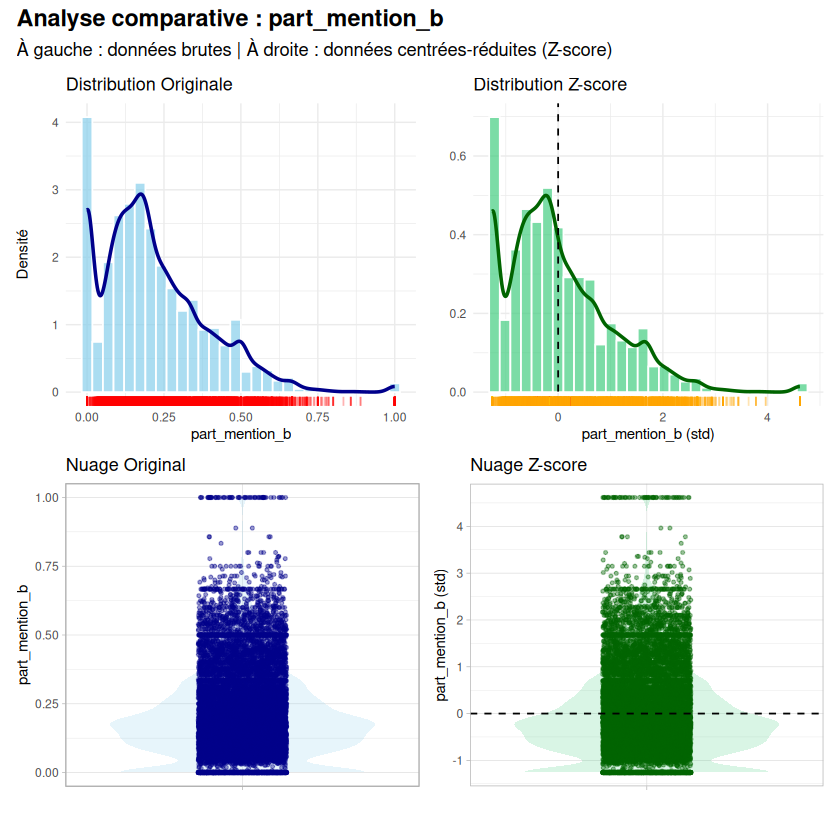

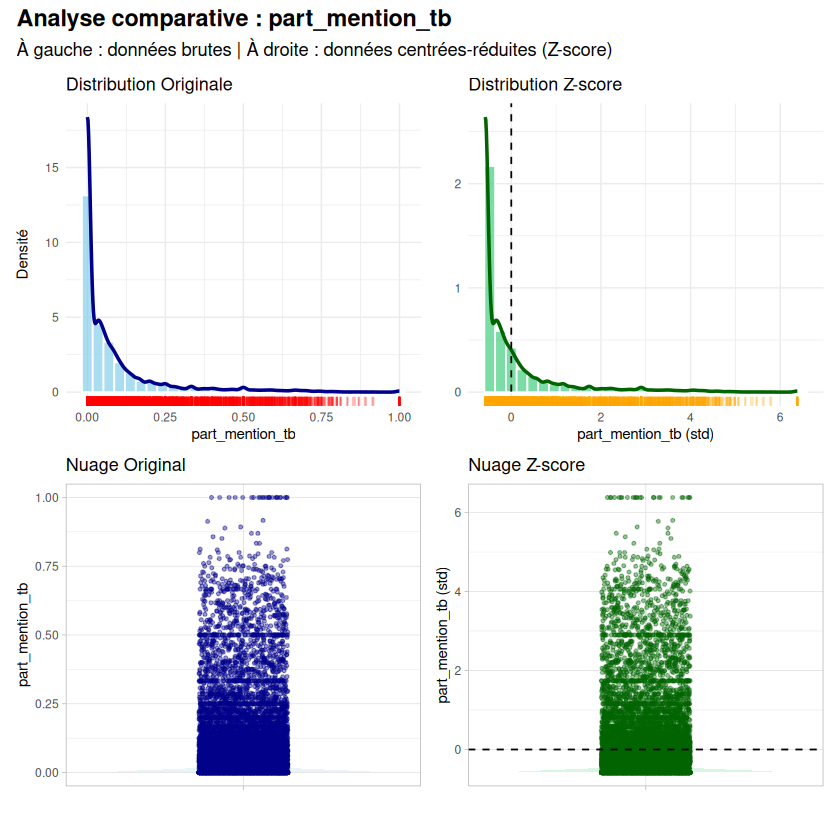

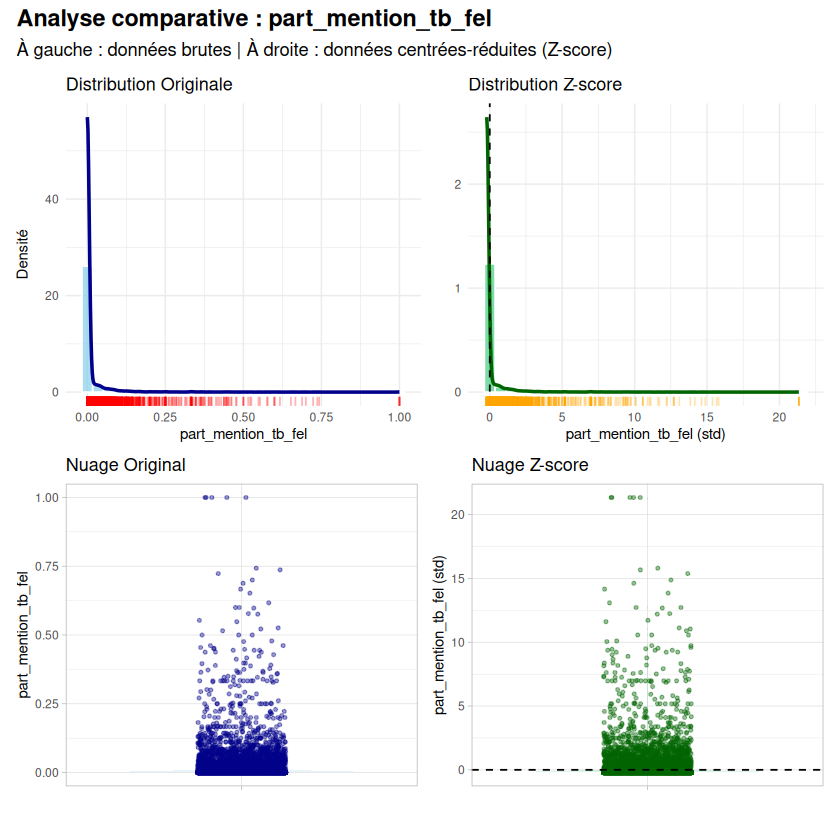

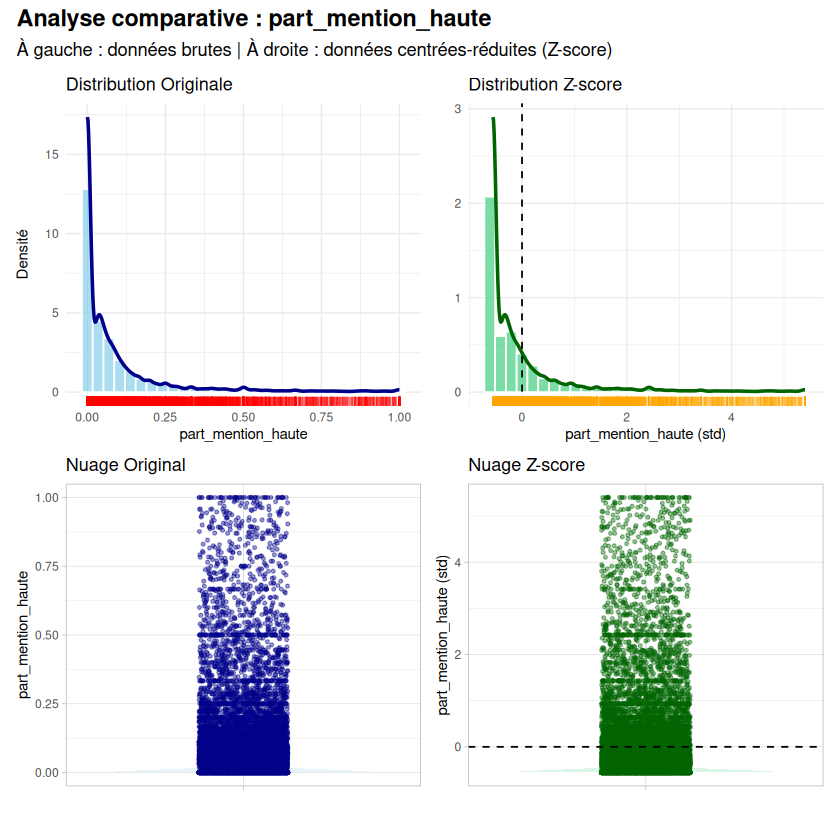

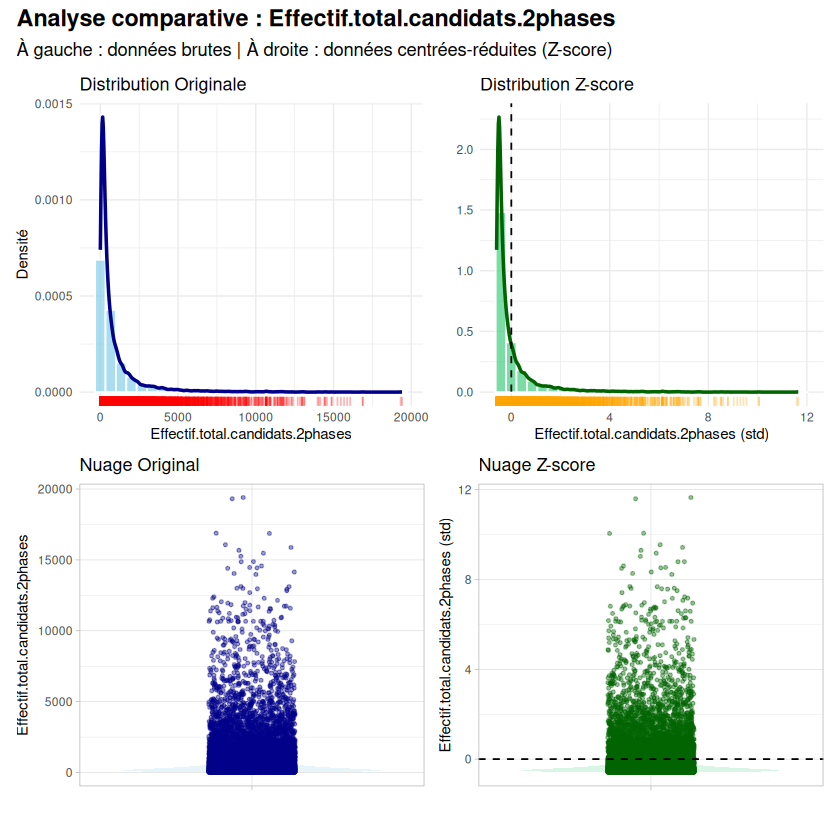

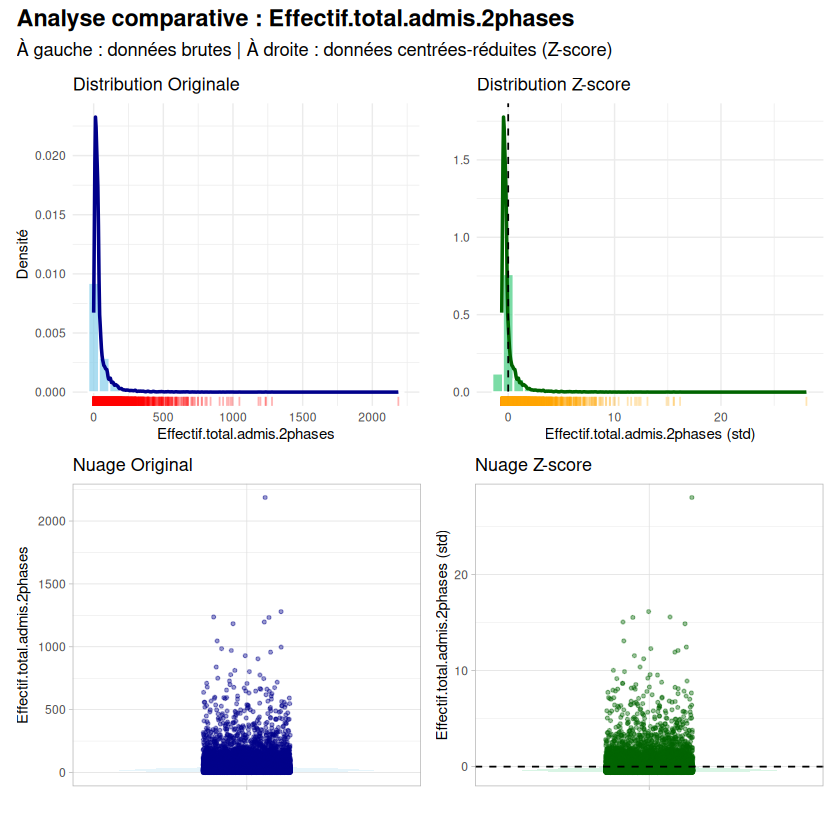

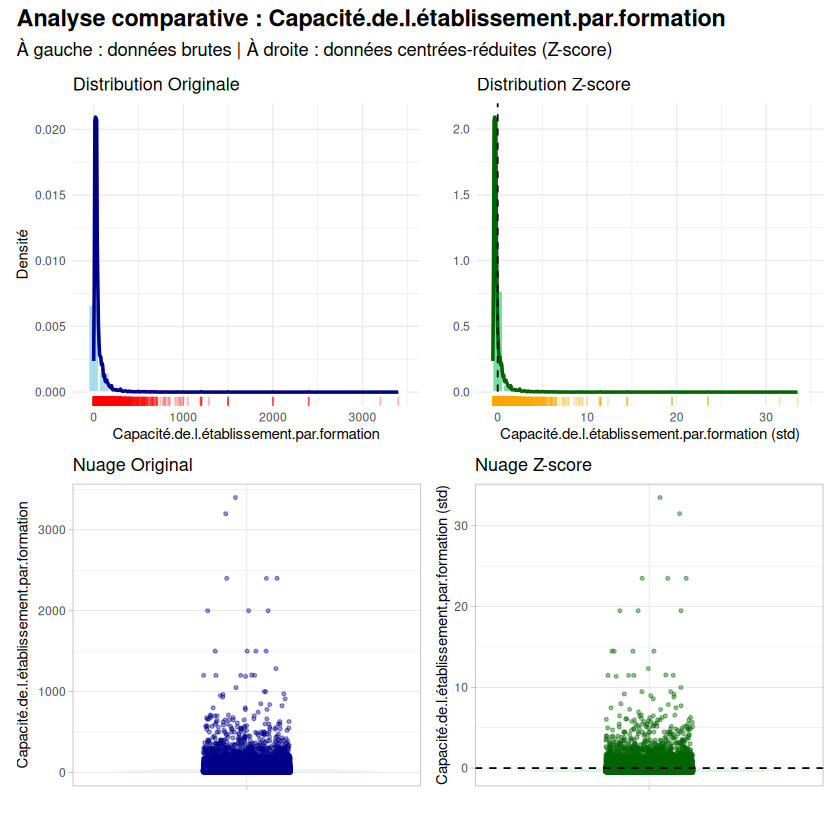

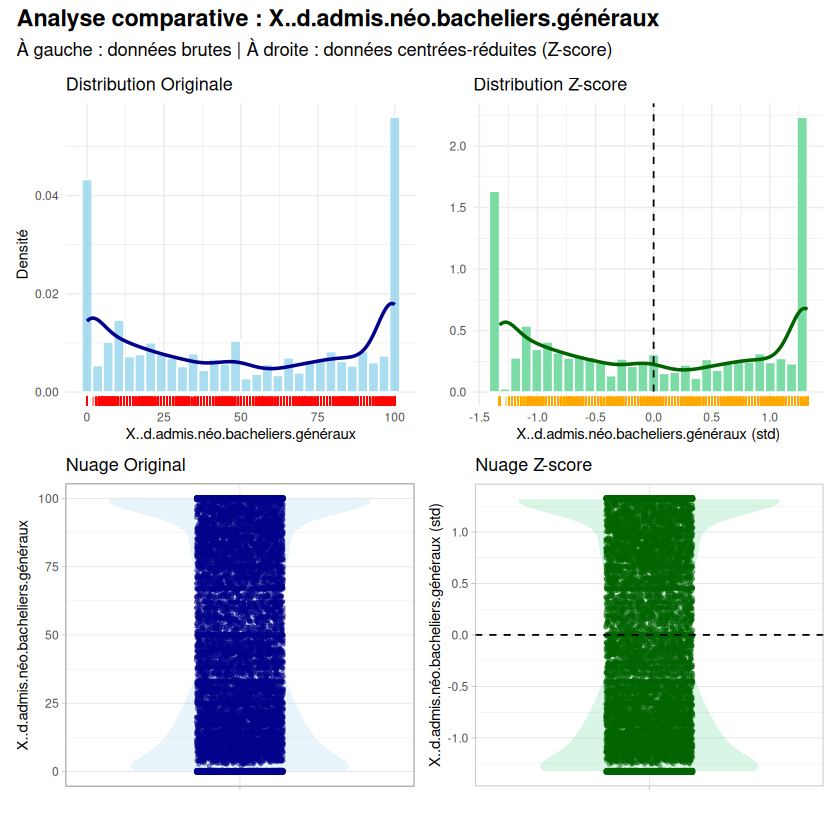

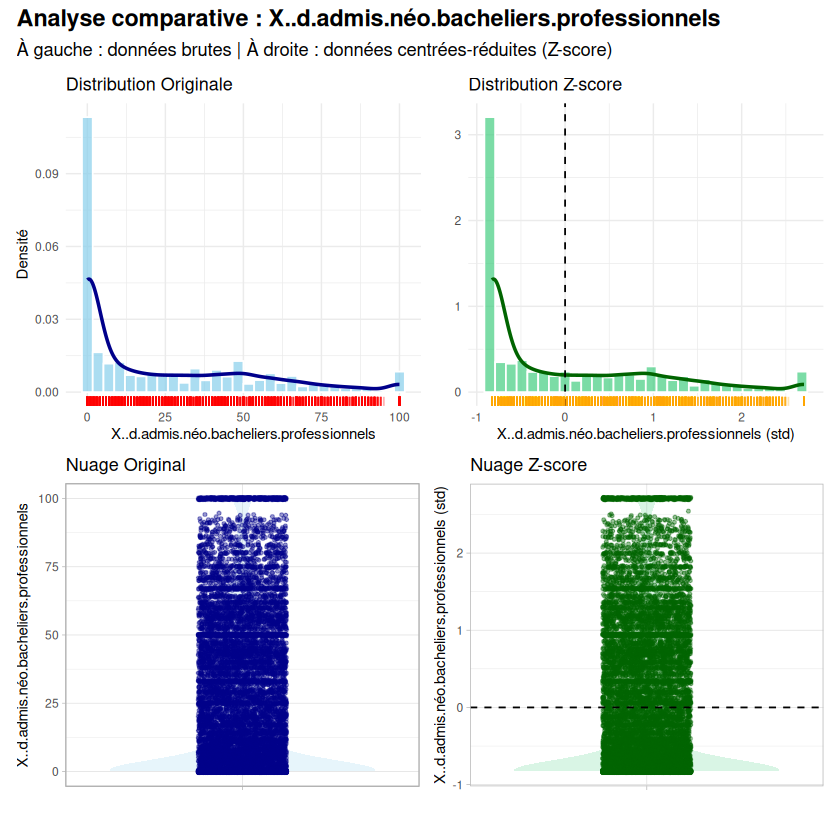

In [5]:
library(ggplot2)
library(patchwork)

 vars_to_plot <- c(

"pression_candidature", "taux_admission", "taux_remplissage",

"taux_acces_num", "score_mention", "pct_filles_admises",

"pct_garcons_admis", "part_mention_ab", "part_mention_b",

"part_mention_tb", "part_mention_tb_fel", "part_mention_haute",

"Effectif.total.candidats.2phases", "Effectif.total.admis.2phases",

"Capacité.de.l.établissement.par.formation","X..d.admis.néo.bacheliers.issus.de.la.même.académie..Paris.Créteil.Versailles.réunies","X..d.admis.néo.bacheliers.généraux","X..d.admis.néo.bacheliers.technologiques ","X..d.admis.néo.bacheliers.professionnels") 

# Boucle principale
for (v in vars_to_plot) {
  
  if (v %in% names(data_features_core)) {
    
    # Préparation d'un dataframe temporaire avec la version centrée-réduite
    df_temp <- data_features_core
    df_temp$v_orig <- df_temp[[v]]
    df_temp$v_scaled <- as.numeric(scale(df_temp[[v]]))
    
    # --- 1. HISTOGRAMME ORIGINAL ---
    p1 <- ggplot(df_temp, aes(x = v_orig)) +
      geom_histogram(aes(y = after_stat(density)), bins = 30, fill = "skyblue", color = "white", alpha = 0.7) +
      geom_density(color = "darkblue", size = 1) +
      geom_rug(alpha = 0.3, color = "red") +
      theme_minimal(base_size = 9) +
      labs(title = "Distribution Originale", x = v, y = "Densité")

    # --- 2. HISTOGRAMME NORMALISÉ ---
    p2 <- ggplot(df_temp, aes(x = v_scaled)) +
      geom_histogram(aes(y = after_stat(density)), bins = 30, fill = "seagreen3", color = "white", alpha = 0.7) +
      geom_density(color = "darkgreen", size = 1) +
      geom_vline(xintercept = 0, linetype = "dashed", color = "black") + # Ligne à la moyenne
      geom_rug(alpha = 0.3, color = "orange") +
      theme_minimal(base_size = 9) +
      labs(title = "Distribution Z-score", x = paste(v, "(std)"), y = "")

    # --- 3. NUAGE DE POINTS ORIGINAL ---
    p3 <- ggplot(df_temp, aes(x = "", y = v_orig)) +
      geom_violin(fill = "skyblue", alpha = 0.2, color = NA) +
      geom_jitter(width = 0.15, alpha = 0.4, color = "darkblue", size = 0.8) +
      theme_light(base_size = 9) +
      labs(title = "Nuage Original", x = "", y = v)

    # --- 4. NUAGE DE POINTS NORMALISÉ ---
    p4 <- ggplot(df_temp, aes(x = "", y = v_scaled)) +
      geom_violin(fill = "seagreen3", alpha = 0.2, color = NA) +
      geom_jitter(width = 0.15, alpha = 0.4, color = "darkgreen", size = 0.8) +
      geom_hline(yintercept = 0, linetype = "dashed", color = "black") +
      theme_light(base_size = 9) +
      labs(title = "Nuage Z-score", x = "", y = paste(v, "(std)"))

    # --- ASSEMBLAGE FINAL ---
    # (p1 | p2) place à côté, / place en dessous
    final_layout <- (p1 + p2) / (p3 + p4) + 
      plot_annotation(
        title = paste("Analyse comparative :", v),
        subtitle = "À gauche : données brutes | À droite : données centrées-réduites (Z-score)",
        theme = theme(plot.title = element_text(face = "bold", size = 14))
      )
    
    print(final_layout)
  }
}

Remarque: pour taux de remplissage on a des valeurs plus grandes que 1 car on accepte plus d'individus qu'il y a de places

In [6]:
##Analyse du taux de remplissage:
# Extraction des établissements avec un taux de remplissage atypique (> 200%)
etabs_atypiques <- data_features_core %>%
  filter(taux_remplissage > 2) %>%
  select(Établissement, Filière.de.formation, taux_remplissage, Sélectivité) %>%
  arrange(desc(taux_remplissage))

# Affichage des 10 premiers pour inspection
print(head(etabs_atypiques, 10))

ERROR: Error in data_features_core %>% filter(taux_remplissage > 2) %>% select(Établissement, : impossible de trouver la fonction "%>%"


# Analyse pluri-dimensionnelle des variables

In [8]:
library(corrplot)

# Sélectionne les variables numériques pour l'étude
# (On utilise les noms issus du script de nettoyage)
cols_etude <- var_quanti

#Calcule la matrice de corrélation
# On utilise use = "complete.obs" pour ignorer les lignes avec des NA
matrice_corr <- cor(data_features_core%>% select(all_of(cols_etude)), use = "complete.obs")

# Affiche la matrice dans la console
print(round(matrice_corr, 2))
par(mar = c(1, 1, 1, 1))  # réduire les marges

png("corrplot.png", width = 2000, height = 2000, res = 150)
# 4. Visualisation graphique (Heatmap)
corrplot(matrice_corr, 
         method = "color",       
         type = "upper",         
         order = "original",       
         addCoef.col = "black",  
         tl.col = "black",
         tl.cex=0.5,
         number.cex = 0.5,       
         diag = FALSE            
)
dev.off()

ERROR: Error: objet 'var_quanti' introuvable


Remarques: 
Pas un lien important entre mention et pression candidature  
la pression candidature est en revanche liée au taux accès 

`geom_smooth()` using formula = 'y ~ x'


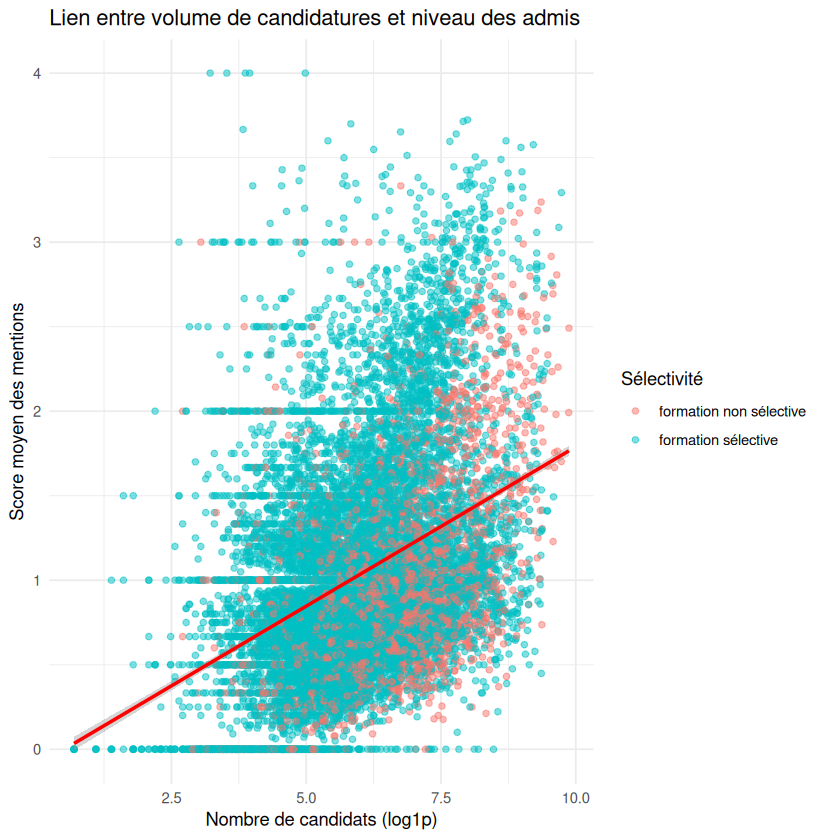

In [ ]:
###Corrélation : Pression vs Niveau académique (Score Mention)

ggplot(data_features_core, aes(x = log_candidats, y = score_mention)) +
  geom_point(aes(color = Sélectivité), alpha = 0.5) +
  geom_smooth(method = "lm", color = "red") +
  labs(
    title = "Lien entre volume de candidatures et niveau des admis",
    x = "Nombre de candidats (log1p)",
    y = "Score moyen des mentions") +
  theme_minimal()

Plus il y a de candidats pour une formation plus leurs notes sont élevée en moyenne  (droite de régression rouge)
entre mentions 3 et 4 (bien/très bien) seulement des formations sélectives semblent être demandées

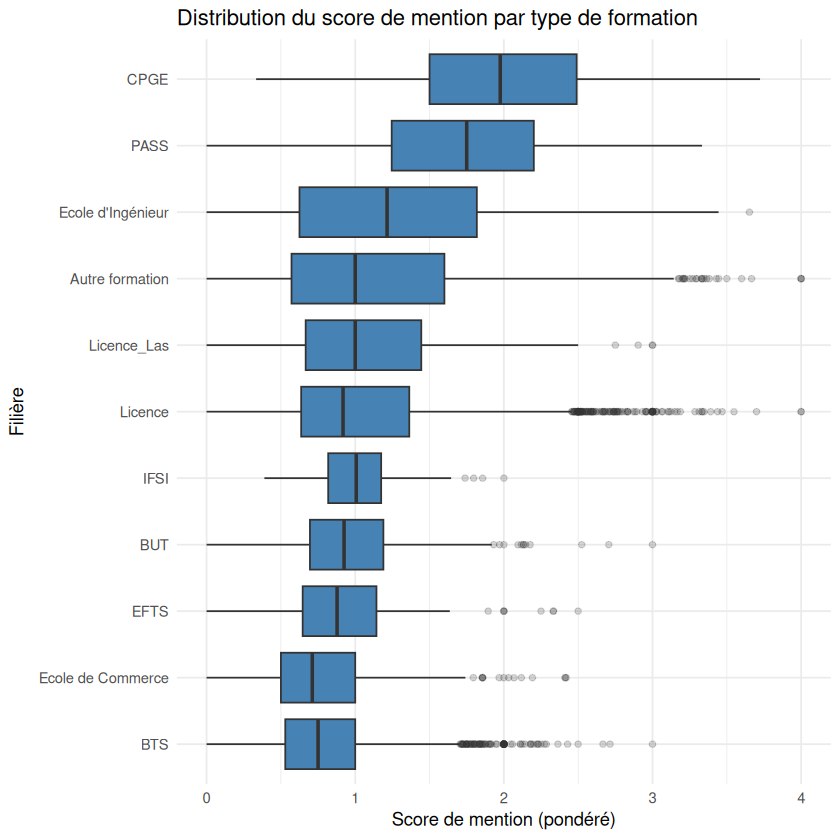

In [ ]:
#Niveau admis par fillières
ggplot(data_features_core, aes(x = reorder(Filière.de.formation.très.agrégée, score_mention), y = score_mention)) +
  geom_boxplot(fill = "steelblue", outlier.alpha = 0.2) +
  coord_flip() + # Pour lire les noms des filières horizontalement
  labs(
    title = "Distribution du score de mention par type de formation",
    x = "Filière",
    y = "Score de mention (pondéré)"
  ) +
  theme_minimal()

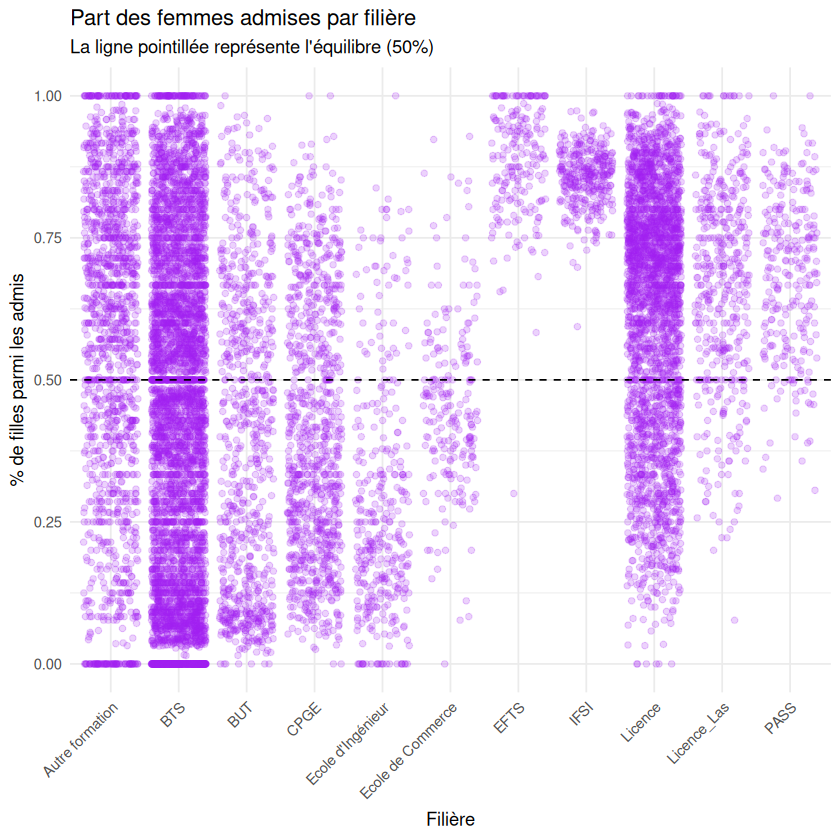

In [ ]:
#Mixité par domaine
data_genre <- data_features_core %>%
  filter(log_admis > 2) # On filtre les petites formations pour la lisibilité

ggplot(data_genre, aes(x = Filière.de.formation.très.agrégée, y = pct_filles_admises)) +
  geom_jitter(alpha = 0.2, color = "purple") + 
  # CORRECTION ICI : yintercept au lieu de y0
  geom_hline(yintercept = 0.5, linetype = "dashed", color = "black") + 
  labs(
    title = "Part des femmes admises par filière",
    subtitle = "La ligne pointillée représente l'équilibre (50%)",
    x = "Filière",
    y = "% de filles parmi les admis"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

In [ ]:
dim(data_features_core)

[1] 14252    31

Welcome! Want to learn more? See two factoextra-related books at https://goo.gl/ve3WBa



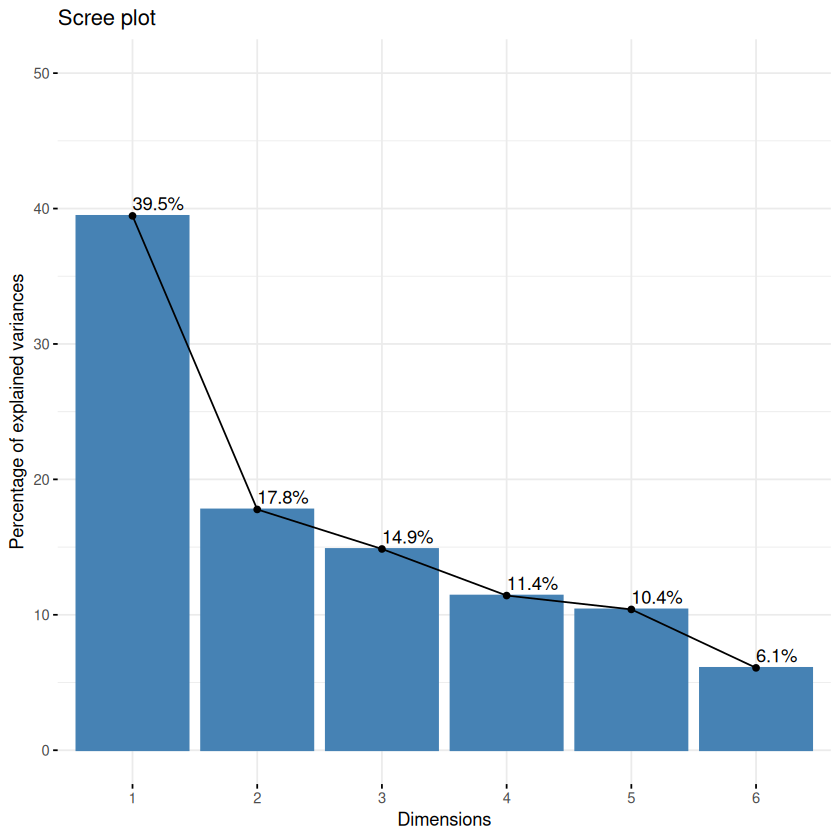

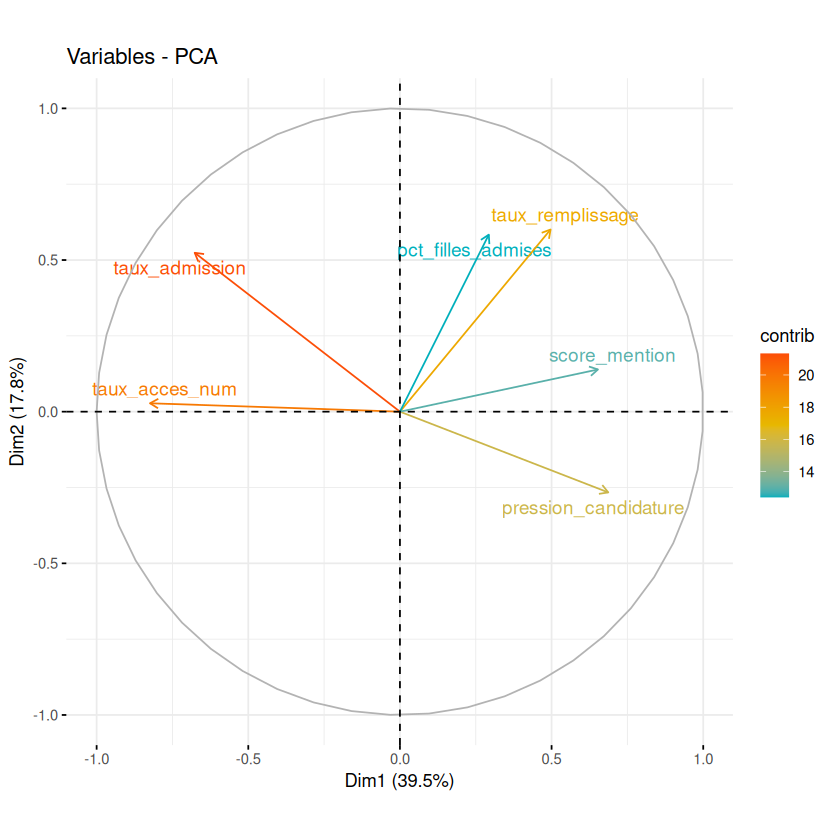

In [ ]:
###ACP
library(FactoMineR)
library(factoextra)
library(tidyr)

# 1. Sélection des variables actives pour l'ACP
# On choisit des ratios plutôt que des volumes bruts pour éviter l'effet de taille
data_pca <- data_features_core %>%
  select(
    pression_candidature,
    taux_admission,
    taux_remplissage,
    taux_acces_num,
    score_mention,
    pct_filles_admises
  ) %>%
  drop_na() # L'ACP nécessite des données complètes

# 2. Exécution de l'ACP
# Les données sont centrées et réduites par défaut (scale.unit = TRUE)
res_pca <- PCA(data_pca, graph = FALSE)

fviz_eig(res_pca, addlabels = TRUE, ylim = c(0, 50))


fviz_pca_var(res_pca, col.var = "contrib", 
             gradient.cols = c("#00AFBB", "#E7B800", "#FC4E07"),
             repel = TRUE)


